# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
import time
print("TensorFlow:", tf.__version__)

2026-06-07 06:22:56.931405: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780813377.193444      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780813377.284868      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780813377.901677      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780813377.901719      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780813377.901722      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [3]:
corpus = '''
Robotics is the interdisciplinary study and practice of the design, construction, operation, and use of robots. A roboticist is someone who specializes in robotics. Robotics usually combines four aspects of design work: a power source (e.g. a battery), mechanical construction, a control system (electrical circuits), and software (run by remote control or artificial intelligence).


The goal of most robotics is to design machines that can assist humans in various fields, such as agriculture, construction, domestic work, food processing, inventory management, manufacturing, medicine, military, mining, space exploration, and transportation.


Robots impact humans by displacing workers. Some expect this to occur at an increasing rate, leading to proposed solutions such as basic income. Robotics is itself a lucrative business that creates careers, especially for postgraduates. Roboticists often aim to create machines that seem to interface naturally with humans. The field is under active research and development, with areas of interest including robot kinematics and quantum robotics.

'''

In [4]:
len(corpus)

1098

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [5]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 110
X shape: (152, 65)
y shape: (152,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

### Math & Architecture Behind SimpleRNN
The Vanilla Recurrent Neural Network (RNN) processes text sequentially by passing a hidden state $h_t$ from one time step to the next. At any step $t$, the current hidden state is calculated using a tanh activation function:

$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$

#### The Vanishing Gradient Problem
Standard RNNs struggle to learn long-range sequence data. During backpropagation through time, gradients are multiplied repeatedly by the weight matrix $W_{hh}$. If these weights are small, the gradients shrink exponentially toward zero ($Gradient \rightarrow 0$). Consequently, the model "forgets" words from earlier parts of the sentence and fails to maintain long-term context.

In [6]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

start = time.time()

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)

rnn_time = time.time() - start

print("Vanilla RNN training completed")

2026-06-07 06:23:13.790617: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Vanilla RNN training completed


### Hyperparameter Modification: Scaling the Vanilla RNN
To see if we can help the SimpleRNN construct better sentence structures, we are upgrading its parameters:
* **Embedding Size ($32 \rightarrow 64$):** Allows the model to represent each word in a richer dimensional vector space, capturing deeper semantic nuances.
* **Hidden Units ($64 \rightarrow 128$):** Expands the network's capacity to memorize sequence paths.
* **Epochs ($100 \rightarrow 200$):** Grants the optimizer double the cycles to find lower loss minima.

In [7]:
rnn_model2 = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model2.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

start = time.time()

rnn_history2 = rnn_model2.fit(X, y, epochs=200, verbose=0)

rnn2_time = time.time() - start

print("Vanilla RNN training completed")

Vanilla RNN training completed


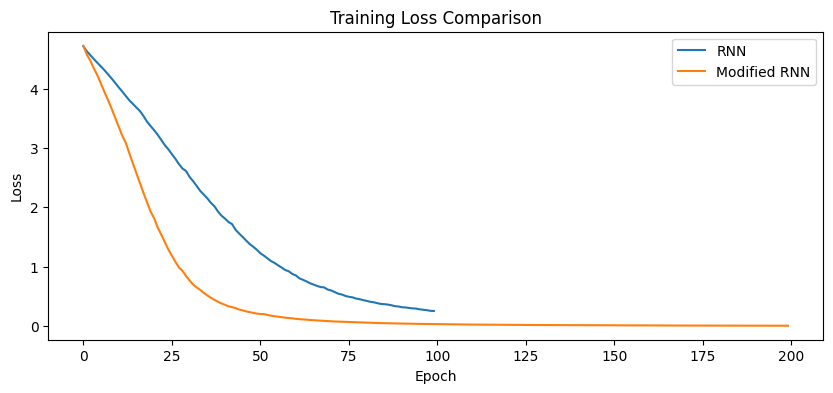

In [8]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(rnn_history2.history['loss'], label='Modified RNN')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

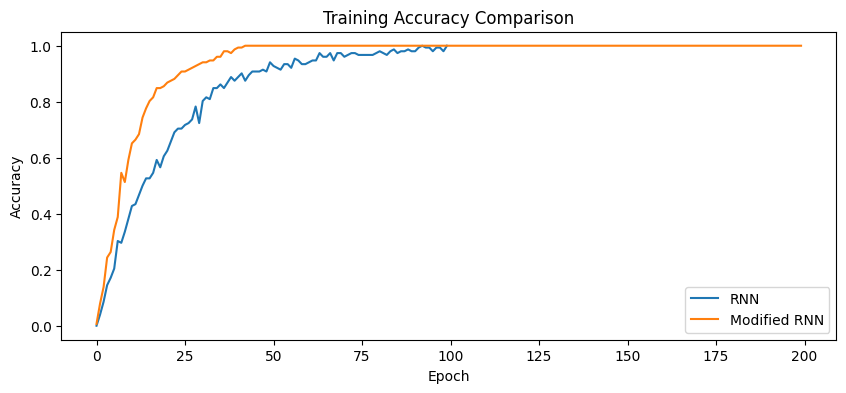

In [9]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['accuracy'], label='RNN')
plt.plot(rnn_history2.history['accuracy'], label='Modified RNN')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.show()

# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

### Math & Architecture Behind LSTM (Long Short-Term Memory)
LSTMs solve the vanishing gradient problem by introducing an internal tracking highway called the **Cell State** ($C_t$), managed by three regulatory filters known as gates:

1. **Forget Gate ($f_t$):** Determines what percentage of old information to discard.
   $$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
2. **Input Gate ($i_t$):** Selects which new pieces of incoming data to store in the cell state.
   $$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
3. **Output Gate ($o_t$):** Governs what the next hidden state ($h_t$) should output based on the newly updated cell state.
   $$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$

Because the cell state calculation relies heavily on element-wise addition rather than strict continuous matrix multiplication, gradients flow uninterrupted backwards through time, retaining memories across long textual distances.

In [10]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

start = time.time()

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)

lstm_time = time.time() - start

print("LSTM training completed")

LSTM training completed


### Hyperparameter Modification: Scaling the LSTM Architecture
While LSTMs excel at retaining semantic memory, adding capacity helps them track complex syntax structures over longer textual spans. We scale up the parameters:
* **Embedding Size:** Doubled to $64$ dimensions.
* **LSTM Units:** Doubled to $128$ cell units.
* **Epochs:** Increased to $200$ steps to allow the multi-gate weight architecture to settle into convergence.

In [11]:
lstm_model2 = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model2.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

start = time.time()

lstm_history2 = lstm_model2.fit(X, y, epochs=200, verbose=0)

lstm2_time = time.time() - start

print("LSTM training completed")

LSTM training completed


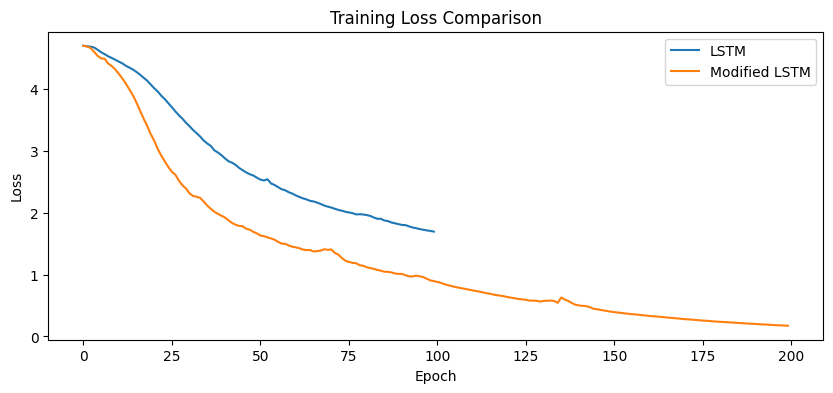

In [12]:
plt.figure(figsize=(10,4))
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(lstm_history2.history['loss'], label='Modified LSTM')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

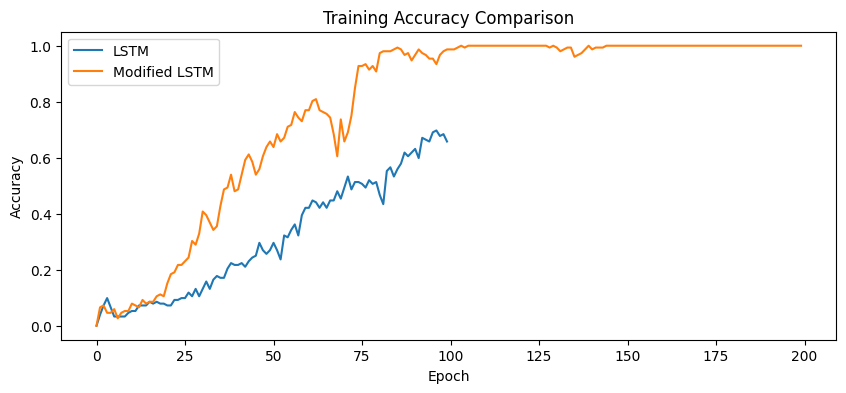

In [13]:
plt.figure(figsize=(10,4))
plt.plot(lstm_history.history['accuracy'], label='LSTM')
plt.plot(lstm_history2.history['accuracy'], label='Modified LSTM')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.show()

# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

### Math & Architecture Behind GRU (Gated Recurrent Unit)
The GRU is a streamlined variant of the LSTM. It merges the cell state and hidden state into a single representation ($h_t$) and uses only two gates, cutting down the total parameter count significantly:

1. **Update Gate ($z_t$):** Functions similarly to a combined forget/input gate, managing how much historic information passes into the future.
   $$z_t = \sigma(W_z \cdot [h_{t-1}, x_t] + b_z)$$
2. **Reset Gate ($r_t$):** Decides how much of past memory to actively brush aside when evaluating new input context.
   $$r_t = \sigma(W_r \cdot [h_{t-1}, x_t] + b_r)$$

**Trade-off:** By eliminating the explicit cell state gate setup, GRUs compute significantly quicker while yielding comparable processing quality on small-to-medium text corpora.

In [14]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

start = time.time()

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)

gru_time = time.time() - start

print("GRU training completed")

GRU training completed


### Hyperparameter Modification: Scaling the GRU Architecture
We test the limits of our structural optimization by giving our GRU variant identical computational weights to our scaled-up LSTM:
* **Embedding Space:** $64$ features.
* **GRU Hidden States:** $128$ structural nodes.
* **Training Window:** $200$ optimization loops.

This adjustment showcases whether the lighter GRU architecture can outperform or match the heavily parameter-dense LSTM under longer execution intervals.

In [15]:
gru_model2 = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model2.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

start = time.time()

gru_history2 = gru_model2.fit(X, y, epochs=200, verbose=0)

gru2_time = time.time() - start

print("GRU training completed")

GRU training completed


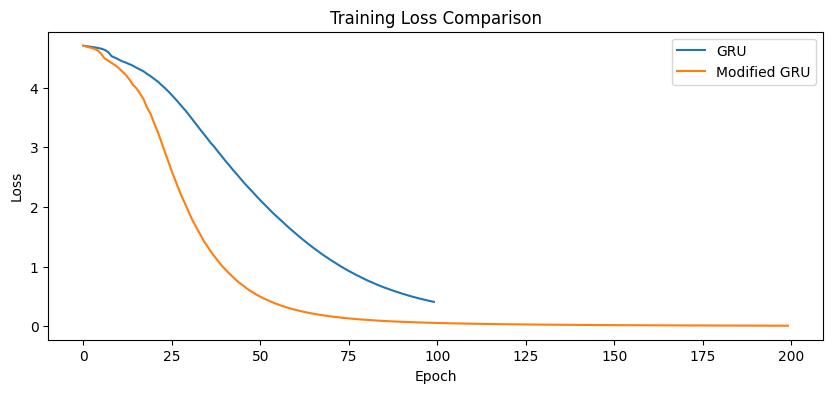

In [16]:
plt.figure(figsize=(10,4))
plt.plot(gru_history.history['loss'], label='GRU')
plt.plot(gru_history2.history['loss'], label='Modified GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

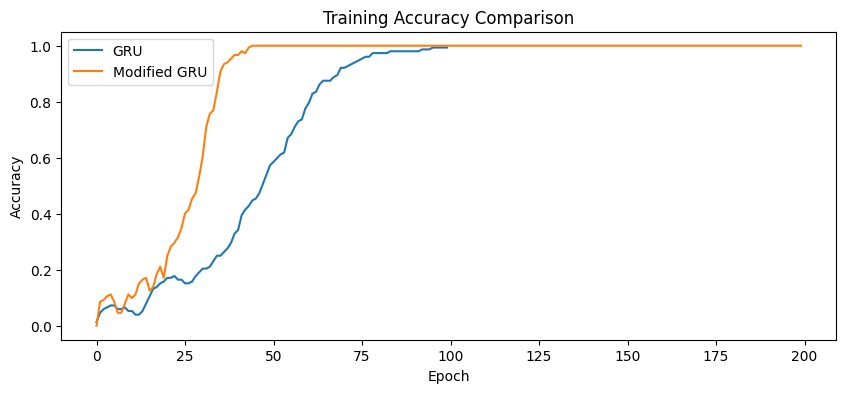

In [17]:
plt.figure(figsize=(10,4))
plt.plot(gru_history.history['accuracy'], label='GRU')
plt.plot(gru_history2.history['accuracy'], label='Modified GRU')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.show()

## 📉 Compare Training Loss

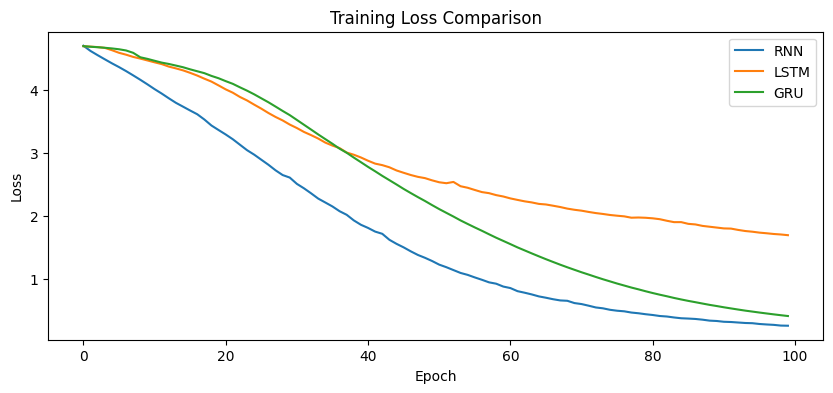

In [18]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

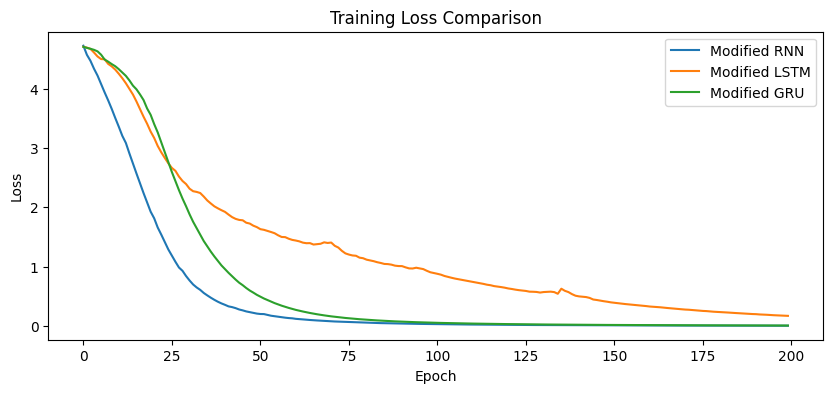

In [19]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history2.history['loss'], label='Modified RNN')
plt.plot(lstm_history2.history['loss'], label='Modified LSTM')
plt.plot(gru_history2.history['loss'], label='Modified GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

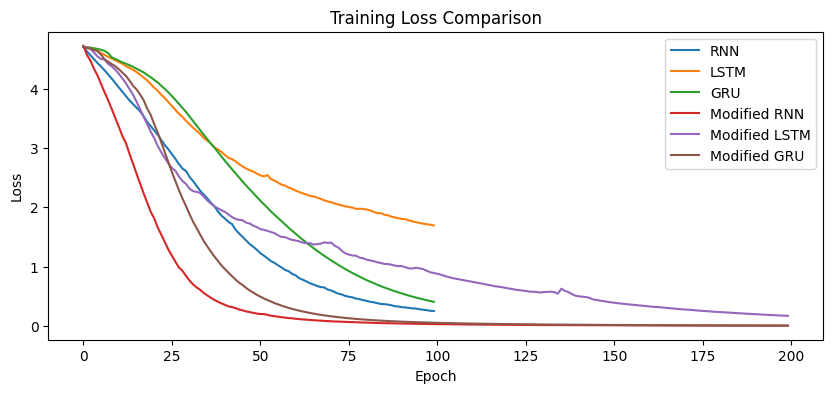

In [20]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.plot(rnn_history2.history['loss'], label='Modified RNN')
plt.plot(lstm_history2.history['loss'], label='Modified LSTM')
plt.plot(gru_history2.history['loss'], label='Modified GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

## Compare Training Accuracy

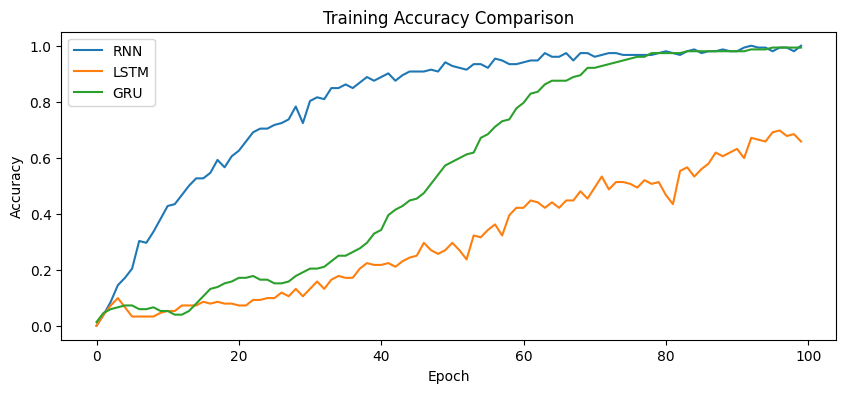

In [21]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['accuracy'], label='RNN')
plt.plot(lstm_history.history['accuracy'], label='LSTM')
plt.plot(gru_history.history['accuracy'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.show()

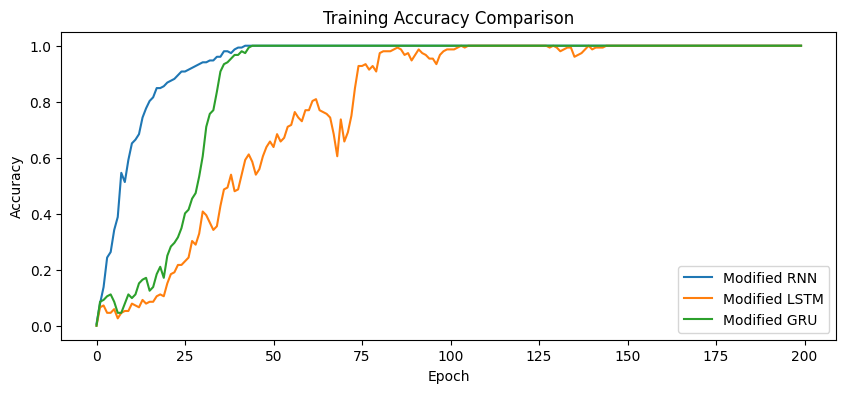

In [22]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history2.history['accuracy'], label='Modified RNN')
plt.plot(lstm_history2.history['accuracy'], label='Modified LSTM')
plt.plot(gru_history2.history['accuracy'], label='Modified GRU')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.show()

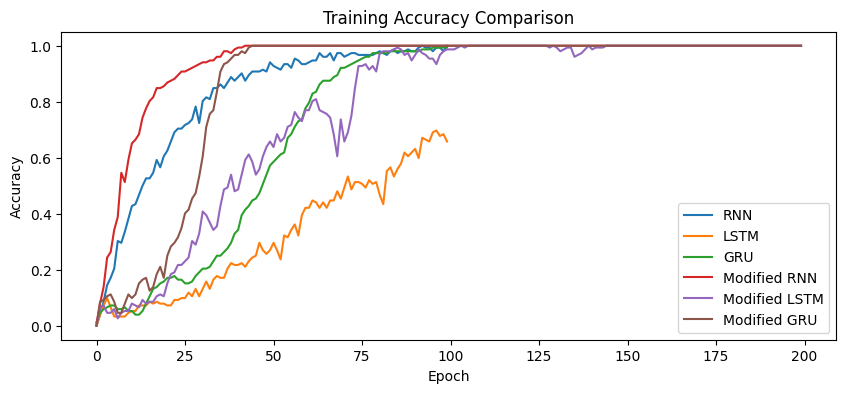

In [23]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['accuracy'], label='RNN')
plt.plot(lstm_history.history['accuracy'], label='LSTM')
plt.plot(gru_history.history['accuracy'], label='GRU')
plt.plot(rnn_history2.history['accuracy'], label='Modified RNN')
plt.plot(lstm_history2.history['accuracy'], label='Modified LSTM')
plt.plot(gru_history2.history['accuracy'], label='Modified GRU')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [24]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [25]:
WORD = "robot"

In [26]:
print(WORD)

robot


In [27]:
print("RNN :", generate_text(rnn_model, WORD, 5))
print("LSTM:", generate_text(lstm_model, WORD, 5))
print("GRU :", generate_text(gru_model, WORD, 5))

RNN : robot is humans interdisciplinary study and
LSTM: robot impact impact is the study
GRU : robot impact humans by displacing workers


In [28]:
print("RNN :", generate_text(rnn_model2, WORD, 10))
print("LSTM:", generate_text(lstm_model2, WORD, 10))
print("GRU :", generate_text(gru_model2, WORD, 10))

RNN : robot goal of most robotics is to design machines that can
LSTM: robot impact humans by displacing workers some expect this to occur
GRU : robot goal of most robotics is to design machines that can


In [29]:
print("RNN :", generate_text(rnn_model2, WORD, max_len))
print()
print("LSTM:", generate_text(lstm_model2, WORD, max_len))
print()
print("GRU :", generate_text(gru_model2, WORD, max_len))

RNN : robot goal of most robotics is to design machines that can assist humans in various fields such as agriculture construction domestic work food processing inventory management manufacturing medicine military mining space exploration and transportation run by remote control or artificial intelligence and development circuits areas of control and robot kinematics and quantum robotics is remote interdisciplinary and software run by remote control or artificial intelligence and software

LSTM: robot impact humans by displacing workers some expect this to occur at an increasing rate leading to proposed solutions such as basic income robotics is itself a lucrative business that creates careers especially for postgraduates roboticists often aim to create machines that seem to interface naturally with humans the field is under active research and development with areas of interest including robot kinematics and quantum robotics robotics

GRU : robot goal of most robotics is to design mach

## Comparison Table

In [30]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "RNN",
        "Modified RNN",
        "LSTM",
        "Modified LSTM",
        "GRU",
        "Modified GRU"
    ],
    "Final Loss": [
        rnn_history.history['loss'][-1],
        rnn_history2.history['loss'][-1],
        lstm_history.history['loss'][-1],
        lstm_history2.history['loss'][-1],
        gru_history.history['loss'][-1],
        gru_history2.history['loss'][-1]
    ],
    "Final Accuracy": [
        rnn_history.history['accuracy'][-1],
        rnn_history2.history['accuracy'][-1],
        lstm_history.history['accuracy'][-1],
        lstm_history2.history['accuracy'][-1],
        gru_history.history['accuracy'][-1],
        gru_history2.history['accuracy'][-1]
    ],
    "Time (s)": [
        rnn_time,
        rnn2_time,
        lstm_time,
        lstm2_time,
        gru_time,
        gru2_time
    ],
    "Parameter Count": [
        rnn_model.count_params(),
        rnn_model2.count_params(),
        lstm_model.count_params(),
        lstm_model2.count_params(),
        gru_model.count_params(),
        gru_model2.count_params()
    ]
})

results

,Model,Final Loss,Final Accuracy,Time (s),Parameter Count
0,RNN,0.256421,1.000000,11.569098,16878
1,Modified RNN,0.008043,1.000000,23.928376,45934
2,LSTM,1.695977,0.657895,17.199231,35502
3,Modified LSTM,0.174140,1.000000,57.784907,120046
4,GRU,0.410611,0.993421,20.506434,29486
5,Modified GRU,0.011082,1.000000,54.943201,95726


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**